In [3]:
#Complete Project

#MLProject: Brain Tumor Cancer Prediction

import warnings
warnings.filterwarnings(action="ignore")

import matplotlib.pyplot as plt

import pandas as pd
pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 1000)

data = pd.read_csv("BrainTumorData.csv")
print( data.head() )

print("Shape of entire dataset: ", data.shape)

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  ...  smoothness_worst  compactness_worst  concavity_worst  concave points_worst  symmetry_worst  fractal_dimension_worst  Unnamed: 32
0    842302         M        17.99         10.38          122.80     1001.0          0.11840  ...            0.1622             0.6656           0.7119                0.2654          0.4601                  0.11890          NaN
1    842517         M        20.57         17.77          132.90     1326.0          0.08474  ...            0.1238             0.1866           0.2416                0.1860          0.2750                  0.08902          NaN
2  84300903         M        19.69         21.25          130.00     1203.0          0.10960  ...            0.1444             0.4245           0.4504                0.2430          0.3613                  0.08758          NaN
3  84348301         M        11.42         20.38           77.58      386.1          0.1

In [4]:
print("\n\nBrainTumor Data description : ")
print(data.describe() )



BrainTumor Data description : 
                 id  radius_mean  texture_mean  perimeter_mean    area_mean  smoothness_mean  compactness_mean  ...  smoothness_worst  compactness_worst  concavity_worst  concave points_worst  symmetry_worst  fractal_dimension_worst  Unnamed: 32
count  5.690000e+02   569.000000    569.000000      569.000000   569.000000       569.000000        569.000000  ...        569.000000         569.000000       569.000000            569.000000      569.000000               569.000000          0.0
mean   3.037183e+07    14.127292     19.289649       91.969033   654.889104         0.096360          0.104341  ...          0.132369           0.254265         0.272188              0.114606        0.290076                 0.083946          NaN
std    1.250206e+08     3.524049      4.301036       24.298981   351.914129         0.014064          0.052813  ...          0.022832           0.157336         0.208624              0.065732        0.061867                 0.018

In [5]:
del data['Unnamed: 32']
print(data.describe() )

                 id  radius_mean  texture_mean  perimeter_mean    area_mean  smoothness_mean  compactness_mean  ...   area_worst  smoothness_worst  compactness_worst  concavity_worst  concave points_worst  symmetry_worst  fractal_dimension_worst
count  5.690000e+02   569.000000    569.000000      569.000000   569.000000       569.000000        569.000000  ...   569.000000        569.000000         569.000000       569.000000            569.000000      569.000000               569.000000
mean   3.037183e+07    14.127292     19.289649       91.969033   654.889104         0.096360          0.104341  ...   880.583128          0.132369           0.254265         0.272188              0.114606        0.290076                 0.083946
std    1.250206e+08     3.524049      4.301036       24.298981   351.914129         0.014064          0.052813  ...   569.356993          0.022832           0.157336         0.208624              0.065732        0.061867                 0.018061
min    8.670000e

In [6]:
data = data.set_index('id')
print("\n\n")
print(data)




         diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  compactness_mean  ...  area_worst  smoothness_worst  compactness_worst  concavity_worst  concave points_worst  symmetry_worst  fractal_dimension_worst
id                                                                                                           ...                                                                                                                                 
842302           M        17.99         10.38          122.80     1001.0          0.11840           0.27760  ...      2019.0           0.16220            0.66560           0.7119                0.2654          0.4601                  0.11890
842517           M        20.57         17.77          132.90     1326.0          0.08474           0.07864  ...      1956.0           0.12380            0.18660           0.2416                0.1860          0.2750                  0.08902
84300903         M        19.

In [7]:
print("\n\n")
print("data.diagnosis.unique() = ", data.diagnosis.unique() )




data.diagnosis.unique() =  ['M' 'B']


In [8]:
#Replace B===>0 and   M==>1
data["diagnosis"]  =  data["diagnosis"].map( { 'B':0,  'M':1 } )
print("\n\n")
print("After updation of diagnosis feature: \n")
print(data)




After updation of diagnosis feature: 

          diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  compactness_mean  ...  area_worst  smoothness_worst  compactness_worst  concavity_worst  concave points_worst  symmetry_worst  fractal_dimension_worst
id                                                                                                            ...                                                                                                                                 
842302            1        17.99         10.38          122.80     1001.0          0.11840           0.27760  ...      2019.0           0.16220            0.66560           0.7119                0.2654          0.4601                  0.11890
842517            1        20.57         17.77          132.90     1326.0          0.08474           0.07864  ...      1956.0           0.12380            0.18660           0.2416                0.1860          0.2750            

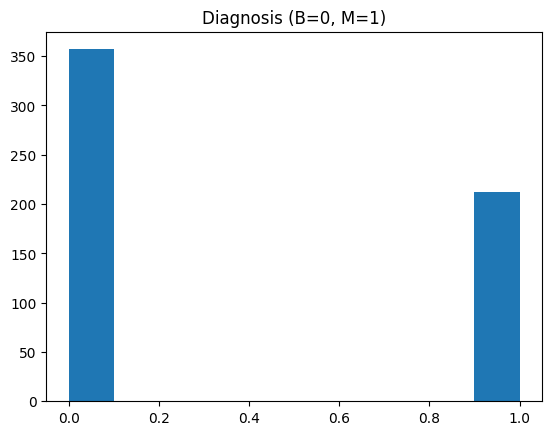

In [9]:
#Data visualisation and pre-procession
plt.hist(data.diagnosis)
plt.title('Diagnosis (B=0, M=1)')
plt.show()

In [10]:
print("\n\n")
print("data.groupby('diagnosis').size()\n")
print( data.groupby('diagnosis').size() )




data.groupby('diagnosis').size()

diagnosis
0    357
1    212
dtype: int64


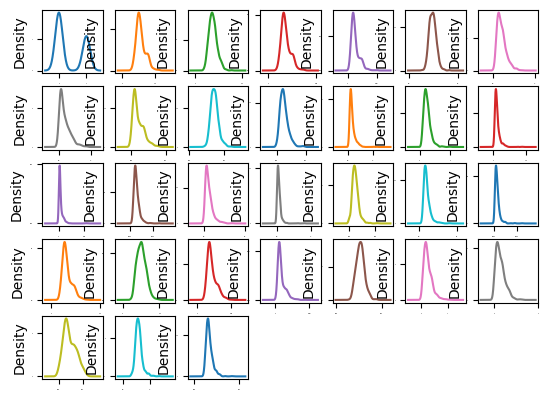

In [11]:
data.plot(kind='density', subplots=True, layout=(5,7), sharex=False, legend=False, fontsize=1)
plt.show()

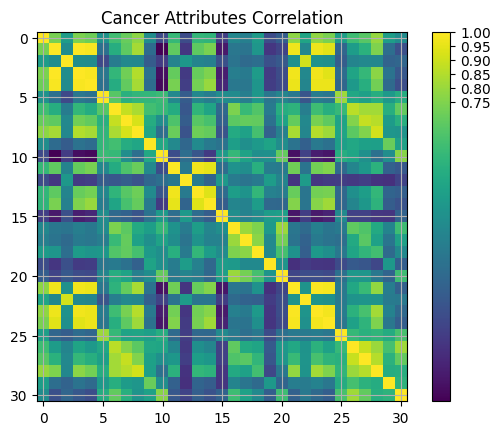

In [12]:
fig = plt.figure()
ax1 = fig.add_subplot(111)
cax = ax1.imshow(data.corr(), interpolation="none")
ax1.grid(True)
plt.title('Cancer Attributes Correlation')
# Add colorbar, make sure to specify tick locations to match desired ticklabels
fig.colorbar(cax, ticks=[.75,.8,.85,.90,.95,1])
plt.show()

In [13]:
#Finally, we'll split the data into predictor variables and target variable,
# following by breaking them into train and test sets. We will use 33% of the data as test set.

Y = data['diagnosis'].values
X = data.drop('diagnosis', axis=1).values

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.33, random_state=21)
#  1       2       3       4

In [16]:
#The following  algorithms will be used,

#1) Classification and Regression Trees (CART),
#2) Support Vector Machines (SVM),
#3) Gaussian Naive Bayes (NB)
#4) k-Nearest Neighbors (KNN).
#5) LogisticRegression (SigmoidFuntion)



from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
import time

In [17]:
models_list = []
models_list.append(('CART', DecisionTreeClassifier()))
models_list.append(('SVM', SVC()))
models_list.append(('NB', GaussianNB()))
models_list.append(('KNN', KNeighborsClassifier()))

In [18]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
num_folds = 10

names   = []
results = []

In [19]:
for name, model in models_list:
    kfold = KFold(n_splits=num_folds, shuffle=True, random_state=123)
    start_Time = time.time()
    cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring='accuracy')
    end_Time = time.time()
    results.append(cv_results)
    names.append(name)
    print( "%-10s: %10f (%f) (run time: %f)" % (name, cv_results.mean(), cv_results.std(), end_Time-start_Time))

CART      :   0.913428 (0.047050) (run time: 0.133866)
SVM       :   0.921323 (0.046931) (run time: 0.052584)
NB        :   0.939474 (0.044113) (run time: 0.023992)
KNN       :   0.921188 (0.040857) (run time: 0.066326)


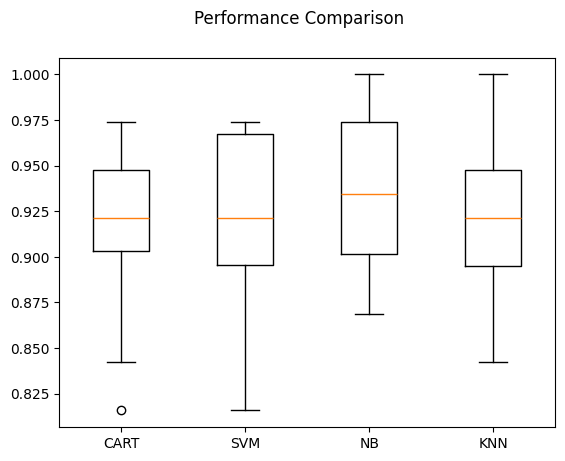

In [20]:
#Performance Comparision
#------------------------------
fig = plt.figure()
fig.suptitle('Performance Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

In [21]:
#Optimize the performance of the algorithms(=models)
#----------------------------------------------------
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [22]:
models_list = []
models_list.append( ('scaledCART',  Pipeline([ ( 'Scaler', StandardScaler() ), ('CART', DecisionTreeClassifier() ) ]) ) )
models_list.append(('ScaledSVM', Pipeline([('Scaler', StandardScaler()),('SVM', SVC( ))])))
models_list.append(('ScaledNB', Pipeline([('Scaler', StandardScaler()),('NB', GaussianNB())])))
models_list.append(('ScaledKNN', Pipeline([('Scaler', StandardScaler()),('KNN', KNeighborsClassifier())])))

In [23]:
num_folds = 10
results = []
names = []

print("\n\n\nAccuracies of algorithm after scaled dataset\n")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    kfold = KFold(n_splits=num_folds, shuffle=True, random_state=123)
    for name, model in models_list:
        start = time.time()
        cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring='accuracy')
        end = time.time()
        results.append(cv_results)
        names.append(name)
        print( "%s: %f (%f) (run time: %f)" % (name, cv_results.mean(), cv_results.std(), end-start))




Accuracies of algorithm after scaled dataset

scaledCART: 0.910796 (0.026690) (run time: 0.149667)
ScaledSVM: 0.973684 (0.026316) (run time: 0.075556)
ScaledNB: 0.928947 (0.044113) (run time: 0.042634)
ScaledKNN: 0.955331 (0.033429) (run time: 0.047092)


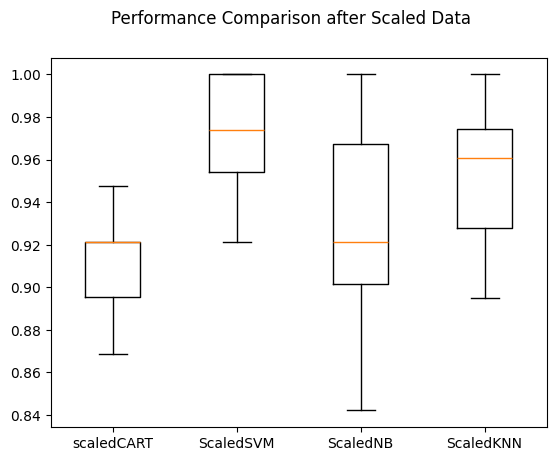

In [24]:
#Performance Comparison after Scaled Data
#----------------------------------------

fig = plt.figure()
fig.suptitle('Performance Comparison after Scaled Data')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Create scaled SVM model
svm_model = Pipeline([
    ('Scaler', StandardScaler()),
    ('SVM', SVC())
])

# Train the model
svm_model.fit(X_train, Y_train)

# Make predictions
Y_pred = svm_model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)

print("Brain Tumor Prediction - Scaled SVM")
print("-----------------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_pred))

# Detailed classification report
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred))

Brain Tumor Prediction - Scaled SVM
-----------------------------------
Accuracy : 0.9627659574468085
Precision: 0.9701492537313433
Recall   : 0.9285714285714286
F1 Score : 0.948905109489051

Confusion Matrix:
[[116   2]
 [  5  65]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       118
           1       0.97      0.93      0.95        70

    accuracy                           0.96       188
   macro avg       0.96      0.96      0.96       188
weighted avg       0.96      0.96      0.96       188

